In [69]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Model, load_model
import os
import glob
from keras.datasets import fashion_mnist
from tensorflow.keras.initializers import GlorotUniform, HeNormal, RandomNormal
from numpy.random import randn, randint

In [70]:
# Load Fashion MNIST dataset

(data, _), (_, _) = fashion_mnist.load_data()

In [71]:
# A function to normalize data
def normalize_data(data):
    # having input values in [-1,1] improves the numerical stability of the optimization problem
    norm_data = (np.float32(data)/255. -0.5) *2.
    norm_data = np.clip(norm_data, -1, 1) # just a sanity check
    return norm_data

# A function to denormalize data
def denormalize_data(norm_data):
    data = 255*(norm_data + 1)/2
    return data

In [72]:
# Normalize the data
norm_data = normalize_data(data)
print('Data shape:', data.shape)

print('Normalized Data shape:', norm_data.shape)
print(norm_data.dtype)

Data shape: (60000, 28, 28)
Normalized Data shape: (60000, 28, 28)
float32


In [73]:
# A function to sample a batch of real data
def sample_real_data(data, numdata):
    random_pos = np.random.choice(len(data), numdata, replace=False)
    X = data[random_pos]
    y = np.ones((numdata, 1)) # the default label for real data is one
    return X, y, random_pos

In [74]:
# a function to visualize a batch of data
def visualizeSamples(data, pos):
    numdata = len(pos)
    ncols = 5
    nrows = int(numdata/ncols);

    fig, axes = plt.subplots(nrows, ncols, figsize=(5, 5))

    k = 0
    for i in range(4):
        for j in range(5):

            axes[i, j].imshow(data[k,:,:], cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f"{pos[k]}")
            k = k+1

    plt.tight_layout()
    plt.show()

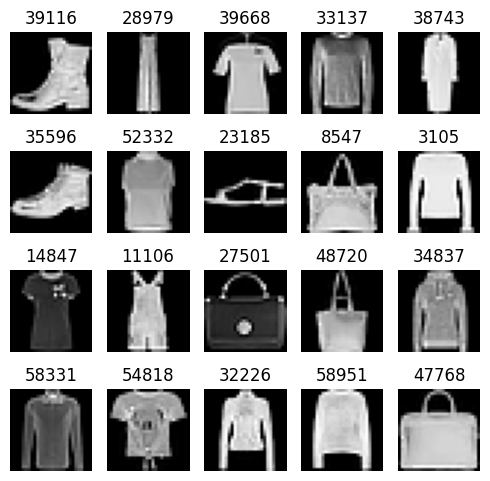

In [75]:
# Select some random data to be used as a reference in the visualization
numdata = 20
samp_data, samp_label, samp_pos = sample_real_data(data, numdata)
# Visualize selected input images
visualizeSamples(samp_data, samp_pos)

In [76]:
# Build Autoencoder
data_conv = np.expand_dims(norm_data, axis=-1)  # Add channel for convolutions
input_shape = data_conv.shape[1:]
print(input_shape)

encoder = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same"),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2), padding="same")
])

encoder.summary()
decoder = keras.Sequential([
    layers.Input(shape=(7,7,16)),
    layers.Conv2DTranspose(16, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),
    layers.Conv2DTranspose(32, (3, 3), activation="relu", padding="same"),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation="tanh", padding="same")
])
decoder.summary()

autoencoder = keras.Sequential([encoder, decoder])


(28, 28, 1)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

...

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose_12             │ (None, 7, 7, 16)       │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 14, 14, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,249 (28.32 KB)

 Trainable params: 7,249 (28.32 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Compile and train Autoencoder
autoencoder.compile(optimizer="adam", loss="mse")
history = autoencoder.fit(norm_data, norm_data, epochs=20, batch_size=16, validation_split=0.2)

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 63s 19ms/step - loss: 0.0370 - val_loss: 0.0228
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - loss: 0.0199 - val_loss: 0.0181
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - loss: 0.0170 - val_loss: 0.0163
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 0.0157 - val_loss: 0.0151
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 0.0149 - val_loss: 0.0153
Epoch 6/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 0.0143 - val_loss: 0.0140
Epoch 7/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 0.0139 - val_loss: 0.0137
Epoch 8/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 0.0136 - val_loss: 0.0133
Epoch 9/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 0.0133 - val_loss: 0.0132
Epoch 10/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 0.0131 - val_loss: 0.0129
Epoch 11/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 54s 18ms/step - loss: 0.0129 - val_loss: 0.0127
Epoch 12

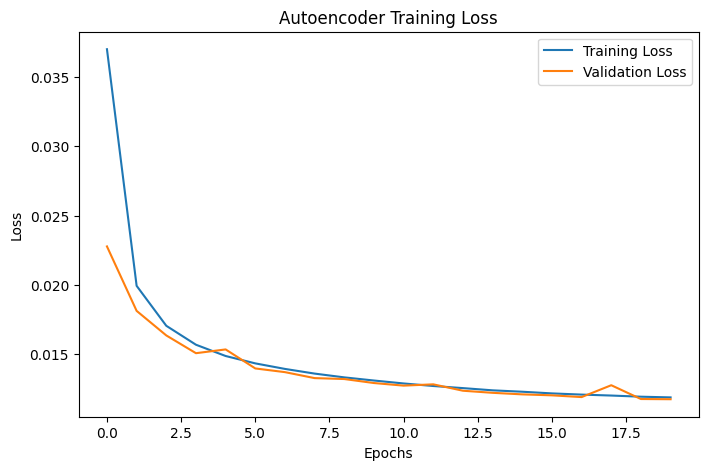

In [78]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
(20, 28, 28, 1)


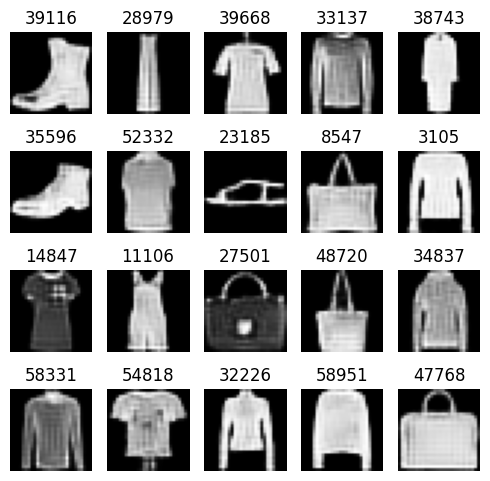

In [79]:
# Generate reconstructed images
samp_data_norm = normalize_data(samp_data)
samp_data_norm = np.expand_dims(samp_data_norm, axis=-1)
encoded_imgs = encoder.predict(samp_data_norm)
decoded_imgs = decoder.predict(encoded_imgs)

print(np.shape(decoded_imgs))

decoded_imgs = denormalize_data(decoded_imgs)

# Visualize selected input images
visualizeSamples(decoded_imgs, samp_pos)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step
Shape of generate data:  (20, 128, 216, 1)


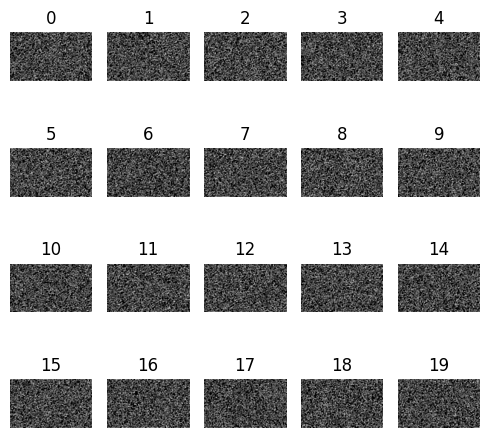

In [80]:
# Try and generate new data with the decoder
# To this purpose we need to start from random noise

random_noise = np.random.rand(numdata, 32, 54, 16)  # It must fit the input of the decoder

# Generate reconstructed images
generated_imgs = decoder.predict(random_noise)

print("Shape of generate data: ", np.shape(generated_imgs))

generated_imgs = denormalize_data(generated_imgs)

# Visualize selected input images
pos = np.arange(numdata)
visualizeSamples(generated_imgs, pos)


In [81]:
# Build a Variational Autoencoder
data_conv = np.expand_dims(norm_data, axis=-1)  # Add channel for convolutions
input_shape = data_conv.shape[1:]
print(input_shape)

latent_dim = 16

# Sampling layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# -------------------------
# Encoder
# -------------------------
encoder_inputs = keras.Input(shape=input_shape)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

shape_before_flatten = keras.backend.int_shape(x)[1:]   # ad es. (7, 7, 16)

x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# -------------------------
# Decoder
# -------------------------
latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(int(np.prod(shape_before_flatten)), activation="relu")(latent_inputs)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(16, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
decoder_outputs = layers.Conv2D(1, (3, 3), activation="tanh", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

# -------------------------
# VAE model
# -------------------------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(inputs - reconstruction), axis=(1, 2, 3))
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        self.add_loss(reconstruction_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

(28, 28, 1)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_26[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 14, 14,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 14, 14,    │      4,624 │ max_pooling2d_18… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 7, 7, 16)  │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 784)       │          0 │ max_pooling2d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     50,240 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      1,040 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      1,040 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 57,264 (223.69 KB)

 Trainable params: 57,264 (223.69 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 784)            │        13,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 7, 7, 16)       │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 14, 14, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,577 (80.38 KB)

 Trainable params: 20,577 (80.38 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
vae.fit(data_conv, data_conv, epochs=20, batch_size=128)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - loss: 129.9460
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 85.2223
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 78.6569
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - loss: 74.9168
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 72.5475
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 70.8450
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 69.7719
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 68.9289
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 68.1455
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 67.6489
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 67.2065
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 66.7469
Epoch 13/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 66.4000
Epoch 14/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 66.0914
Epoch 15/20
46

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
(20, 28, 28, 1)


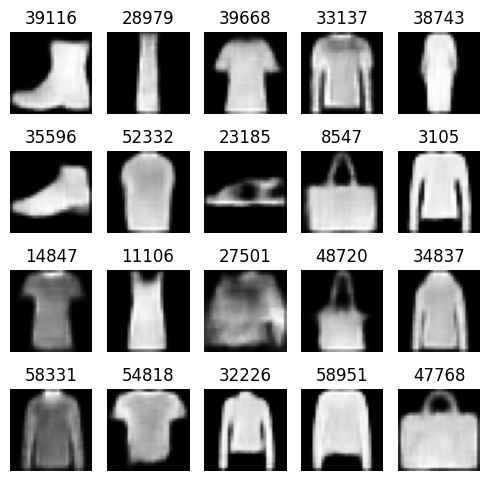

In [83]:
# Generate reconstructed images
samp_data_norm = normalize_data(samp_data)
samp_data_norm = np.expand_dims(samp_data_norm, axis=-1)

z_mean, z_log_var, z = encoder.predict(samp_data_norm)
decoded_imgs = decoder.predict(z)

print(np.shape(decoded_imgs))

decoded_imgs = denormalize_data(decoded_imgs)

# Remove channel dimension if needed
decoded_imgs = np.squeeze(decoded_imgs, axis=-1)

# Visualize selected input images
visualizeSamples(decoded_imgs, samp_pos)

In [84]:
# Build a GAN composed of fully connected layers
def build_generator(latent_dim):
    model = tf.keras.Sequential([

        layers.Input(shape=(latent_dim,)),
        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(512),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1024),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(28*28*1, activation="tanh"),
        layers.Reshape((28,28,1))

    ])
    return model

def build_discriminator(input_shape):
    model = keras.Sequential([

        layers.Input(shape=input_shape),
        layers.Flatten(),

        layers.Dense(1024),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Dense(512),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")

    ])

    opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])\

    return model

In [85]:
# Build the generator and discriminator models
latent_dim = 5
input_shape = (28, 28, 1)

print("Input shape for discriminator:", input_shape)

discriminator = build_discriminator(input_shape)

print("DISCRIMINATOR")
discriminator.summary()

generator = build_generator(latent_dim)

print("GENERATOR")
generator.summary()

Input shape for discriminator: (28, 28, 1)
DISCRIMINATOR


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,225 (5.57 MB)

 Trainable params: 1,460,225 (5.57 MB)

...

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,462,032 (5.58 MB)

 Trainable params: 1,462,032 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# Build the GAN
def define_gan(g_model, d_model, latent_dim):
    d_model.trainable = False # This means that when training the generator, the discriminator is not trained

    # Define the input for the GAN (which is the input for the generator)
    gan_input = keras.Input(shape=(latent_dim,))

    # Connect the generator to this input
    generated_image = g_model(gan_input)

    # Connect the discriminator to the generated image
    gan_output = d_model(generated_image)

    # Create the GAN model
    gan_model = keras.Model(gan_input, gan_output)

    opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    gan_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return gan_model

# Explicitly build the generator and discriminator by calling them with dummy inputs
# This ensures their .input and .output attributes are populated before define_gan is called.
dummy_latent_input = tf.zeros((1, latent_dim))
_ = generator(dummy_latent_input) # Call generator to build it

dummy_image_input = tf.zeros((1, *input_shape))
_ = discriminator(dummy_image_input) # Call discriminator to build it

gan_model = define_gan(generator, discriminator, latent_dim)
gan_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_18 (Sequential)      │ (None, 28, 28, 1)      │     1,462,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_17 (Sequential)      │ (None, 1)              │     1,460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,922,257 (11.15 MB)

 Trainable params: 1,462,032 (5.58 MB)

 Non-trainable params: 1,460,225 (5.57 MB)

In [87]:
# A function to generate random inputs for the decoder
def generate_latent_points(latent_dim, n_samples):
    x = randn(latent_dim * n_samples)
    z = x.reshape(n_samples, latent_dim)
    return z

# A function to generate a fake input from a random point
def generate_fake_samples(g_model, latent_dim, n_batch):
    z_input = generate_latent_points(latent_dim, n_batch)
    
    X_fake = g_model.predict(z_input, verbose=0)
    X_fake = np.array(X_fake, dtype=np.float32)
    
    y_fake = np.zeros((n_batch, 1), dtype=np.float32)
    return X_fake, y_fake

In [88]:
# Some functions to check the performance


# To plot the loss ofdiscriminator and generator
def plot_loss(d_loss, g_loss, dim):
    plt.close()
    plt.figure(figsize=dim)
    plt.plot(d_loss)
    plt.plot(g_loss)
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Iteration')
    plt.legend(['Discriminator', 'Generator'], loc='upper right')
    plt.show()

# To plot the accuracy ofdiscriminator and generator
def plot_acc(d_acc,g_acc, dim):
    plt.close()
    plt.figure(figsize=dim)
    plt.plot(d_acc)
    plt.plot(g_acc)
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Iteration')
    plt.legend(['Discriminator', 'Generator'], loc='upper right')
    plt.show()

In [89]:
def train(g_model, d_model, gan_model, X_train, latent_dim, n_epochs=100, n_batch=64):

    bat_per_epo = int(X_train.shape[0] / n_batch)
    n_steps = bat_per_epo * n_epochs

    d_loss_vec = []
    g_loss_vec = []

    d_acc_vec = [];
    g_acc_vec = [];

    for i in range(n_steps):

        d_loss_b = []
        g_loss_b = []

        d_acc_b = [];
        g_acc_b = [];

        X_real, y_real,_ = sample_real_data(X_train, n_batch) # sample real data

        print(np.shape(X_real))
        X_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_batch) # generate fake data

        # Training the discriminator
        d_loss_r, d_acc_r = d_model.train_on_batch(X_real, y_real) # training step on real data
        d_loss_f, d_acc_f = d_model.train_on_batch(X_fake, y_fake) # training step on fake data

        d_loss_b.append((d_loss_r + d_loss_f)/2)
        d_acc_b.append((d_acc_r + d_acc_f)/2)

        # Training the generator (i.e. training the GAN)
        z_input = generate_latent_points(latent_dim, n_batch)
        y_gan = np.ones((n_batch, 1))
        g_loss, g_acc = gan_model.train_on_batch(z_input, y_gan)

        g_loss_b.append(g_loss)
        g_acc_b.append(g_acc)

        print('>%d, D loss-acc [%.3f,%.3f], G/GAN loss-acc [%.3f,%.3f]' % (i+1, (d_loss_r + d_loss_f)/2, (d_loss_f + d_loss_f)/2, g_loss,g_acc))

        if (i+1) % (bat_per_epo * 1) == 0:

            summarize_performance(i, g_model)

            d_loss_vec.append(np.mean(d_loss_b))
            g_loss_vec.append(np.mean(g_loss_b))
            d_acc_vec.append(np.mean(d_acc_b))
            g_acc_vec.append(np.mean(g_acc_b))

            d_loss_b = []
            g_loss_b = []

            d_acc_b = [];
            g_acc_b = [];

            plot_loss(d_loss_vec,g_loss_vec, (6,4))
            plot_acc(d_acc_vec,g_acc_vec, (6,4))


(128, 28, 28)
>1, D loss-acc [0.498,0.570], G/GAN loss-acc [0.675,0.812]
(128, 28, 28)
>2, D loss-acc [0.578,0.605], G/GAN loss-acc [0.649,0.906]
(128, 28, 28)
>3, D loss-acc [0.589,0.611], G/GAN loss-acc [0.625,0.938]
(128, 28, 28)
>4, D loss-acc [0.611,0.629], G/GAN loss-acc [0.601,0.953]
(128, 28, 28)
>5, D loss-acc [0.626,0.645], G/GAN loss-acc [0.576,0.962]
(128, 28, 28)
>6, D loss-acc [0.649,0.669], G/GAN loss-acc [0.552,0.969]
(128, 28, 28)
>7, D loss-acc [0.671,0.689], G/GAN loss-acc [0.527,0.973]
(128, 28, 28)
>8, D loss-acc [0.693,0.714], G/GAN loss-acc [0.501,0.977]
(128, 28, 28)
>9, D loss-acc [0.721,0.744], G/GAN loss-acc [0.476,0.979]
(128, 28, 28)
>10, D loss-acc [0.752,0.777], G/GAN loss-acc [0.450,0.981]
(128, 28, 28)
>11, D loss-acc [0.788,0.813], G/GAN loss-acc [0.425,0.983]
(128, 28, 28)
>12, D loss-acc [0.827,0.857], G/GAN loss-acc [0.402,0.984]
(128, 28, 28)
>13, D loss-acc [0.870,0.901], G/GAN loss-acc [0.381,0.986]
(128, 28, 28)
>14, D loss-acc [0.917,0.950], G/

>468, D loss-acc [5.026,5.029], G/GAN loss-acc [0.013,1.000]
>Saved: model_0468.h5


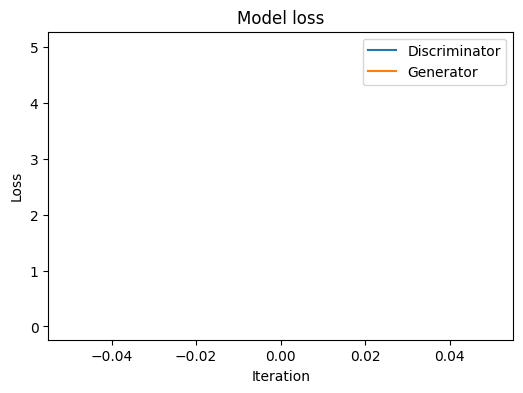

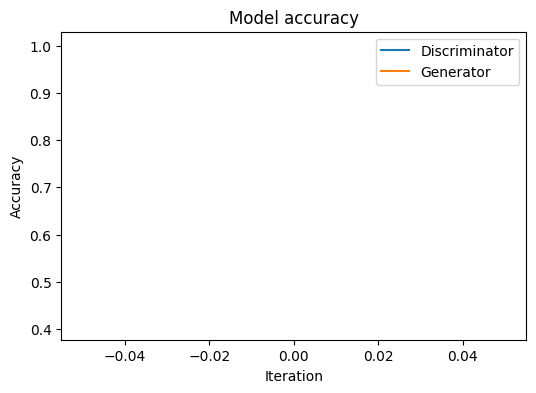

(128, 28, 28)
>469, D loss-acc [5.028,5.031], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>470, D loss-acc [5.029,5.033], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>471, D loss-acc [5.031,5.034], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>472, D loss-acc [5.033,5.036], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>473, D loss-acc [5.034,5.038], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>474, D loss-acc [5.036,5.040], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>475, D loss-acc [5.039,5.042], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>476, D loss-acc [5.041,5.044], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>477, D loss-acc [5.043,5.046], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>478, D loss-acc [5.045,5.048], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>479, D loss-acc [5.047,5.050], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>480, D loss-acc [5.049,5.052], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>481, D loss-acc [5.051,5.054], G/GAN loss-acc [0.012,1.000]
(128, 28, 28)
>482, D los

>936, D loss-acc [5.615,5.616], G/GAN loss-acc [0.006,1.000]
>Saved: model_0936.h5


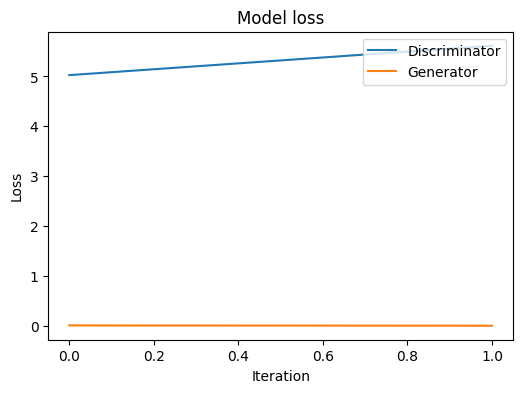

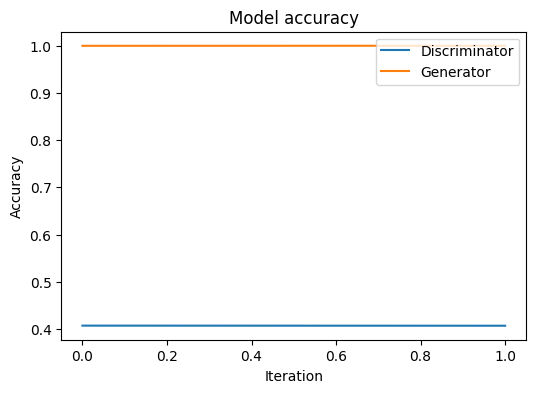

(128, 28, 28)
>937, D loss-acc [5.615,5.617], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>938, D loss-acc [5.616,5.618], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>939, D loss-acc [5.617,5.619], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>940, D loss-acc [5.618,5.620], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>941, D loss-acc [5.619,5.620], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>942, D loss-acc [5.620,5.621], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>943, D loss-acc [5.620,5.622], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>944, D loss-acc [5.621,5.623], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>945, D loss-acc [5.622,5.624], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>946, D loss-acc [5.623,5.625], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>947, D loss-acc [5.624,5.626], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>948, D loss-acc [5.625,5.626], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>949, D loss-acc [5.625,5.627], G/GAN loss-acc [0.006,1.000]
(128, 28, 28)
>950, D los

>Saved: model_1404.h5


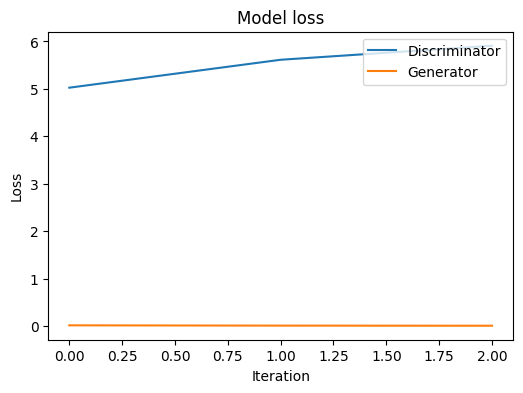

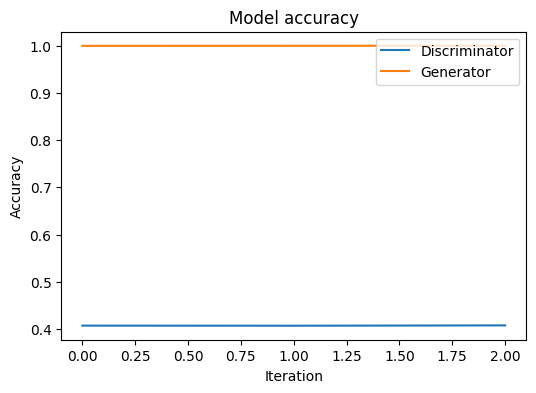

(128, 28, 28)
>1405, D loss-acc [5.911,5.913], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1406, D loss-acc [5.912,5.913], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1407, D loss-acc [5.912,5.913], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1408, D loss-acc [5.913,5.914], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1409, D loss-acc [5.913,5.914], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1410, D loss-acc [5.914,5.915], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1411, D loss-acc [5.914,5.916], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1412, D loss-acc [5.915,5.916], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1413, D loss-acc [5.915,5.917], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1414, D loss-acc [5.916,5.917], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1415, D loss-acc [5.916,5.918], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1416, D loss-acc [5.917,5.918], G/GAN loss-acc [0.004,1.000]
(128, 28, 28)
>1417, D loss-acc [5.917,5.918], G/GAN loss-acc [0.004,1.000]
(128, 28, 28

>1871, D loss-acc [6.100,6.101], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1872, D loss-acc [6.100,6.101], G/GAN loss-acc [0.003,1.000]
>Saved: model_1872.h5


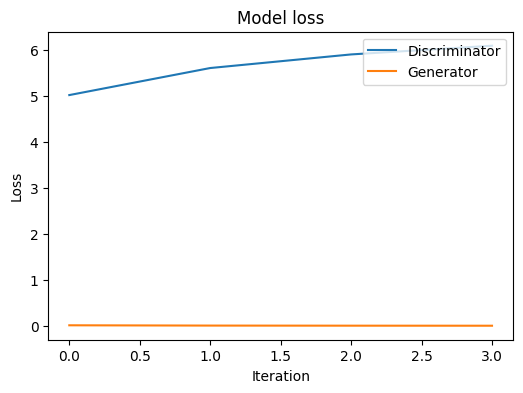

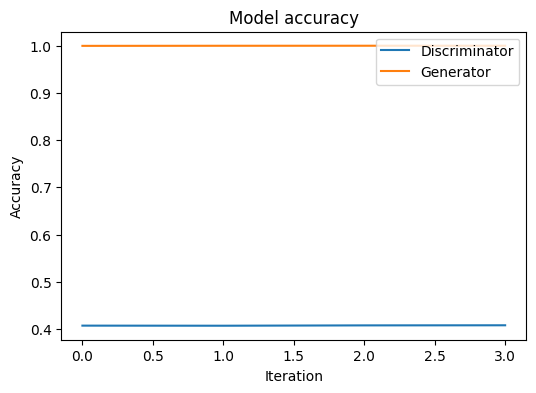

(128, 28, 28)
>1873, D loss-acc [6.101,6.102], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1874, D loss-acc [6.101,6.102], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1875, D loss-acc [6.101,6.102], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1876, D loss-acc [6.102,6.103], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1877, D loss-acc [6.102,6.103], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1878, D loss-acc [6.103,6.104], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1879, D loss-acc [6.103,6.104], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1880, D loss-acc [6.103,6.104], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1881, D loss-acc [6.104,6.105], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1882, D loss-acc [6.104,6.105], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1883, D loss-acc [6.104,6.105], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1884, D loss-acc [6.105,6.106], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>1885, D loss-acc [6.105,6.106], G/GAN loss-acc [0.003,1.000]
(128, 28, 28

>2340, D loss-acc [6.233,6.234], G/GAN loss-acc [0.003,1.000]
>Saved: model_2340.h5


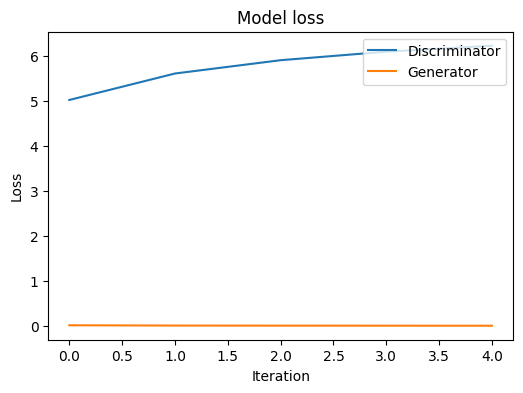

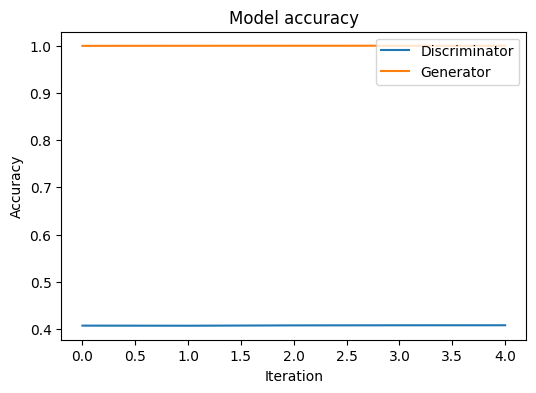

(128, 28, 28)
>2341, D loss-acc [6.233,6.234], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2342, D loss-acc [6.234,6.234], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2343, D loss-acc [6.234,6.235], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2344, D loss-acc [6.234,6.235], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2345, D loss-acc [6.234,6.235], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2346, D loss-acc [6.235,6.235], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2347, D loss-acc [6.235,6.236], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2348, D loss-acc [6.235,6.236], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2349, D loss-acc [6.235,6.236], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2350, D loss-acc [6.236,6.236], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2351, D loss-acc [6.236,6.237], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2352, D loss-acc [6.236,6.237], G/GAN loss-acc [0.003,1.000]
(128, 28, 28)
>2353, D loss-acc [6.236,6.237], G/GAN loss-acc [0.003,1.000]
(128, 28, 28

>2808, D loss-acc [6.336,6.337], G/GAN loss-acc [0.002,1.000]
>Saved: model_2808.h5


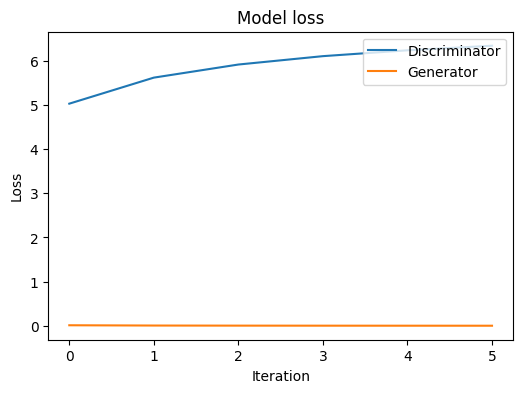

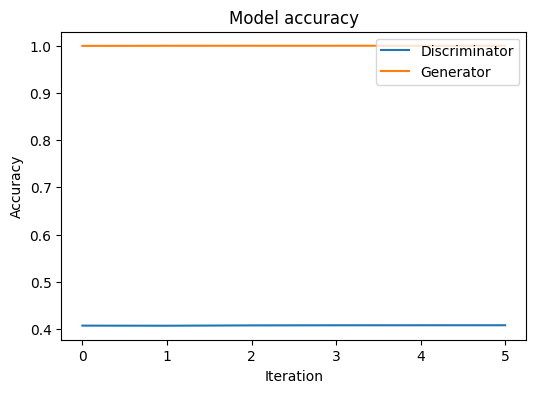

(128, 28, 28)
>2809, D loss-acc [6.337,6.337], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2810, D loss-acc [6.337,6.337], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2811, D loss-acc [6.337,6.338], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2812, D loss-acc [6.337,6.338], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2813, D loss-acc [6.337,6.338], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2814, D loss-acc [6.338,6.338], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2815, D loss-acc [6.338,6.338], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2816, D loss-acc [6.338,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2817, D loss-acc [6.338,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2818, D loss-acc [6.338,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2819, D loss-acc [6.338,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2820, D loss-acc [6.339,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>2821, D loss-acc [6.339,6.339], G/GAN loss-acc [0.002,1.000]
(128, 28, 28

>3276, D loss-acc [6.420,6.421], G/GAN loss-acc [0.002,1.000]
>Saved: model_3276.h5


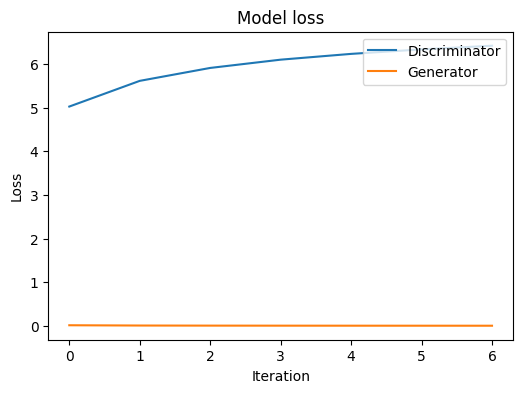

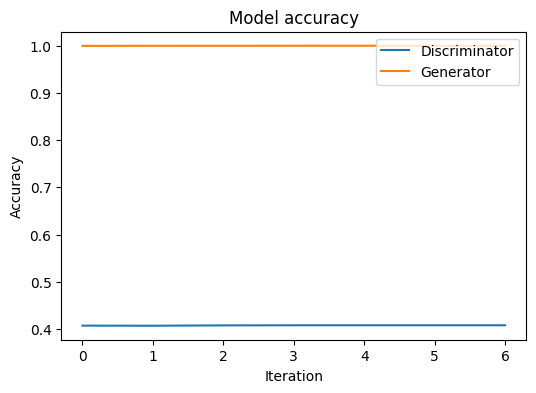

(128, 28, 28)
>3277, D loss-acc [6.420,6.421], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3278, D loss-acc [6.420,6.421], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3279, D loss-acc [6.421,6.421], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3280, D loss-acc [6.421,6.421], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3281, D loss-acc [6.421,6.421], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3282, D loss-acc [6.421,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3283, D loss-acc [6.421,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3284, D loss-acc [6.421,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3285, D loss-acc [6.422,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3286, D loss-acc [6.422,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3287, D loss-acc [6.422,6.422], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3288, D loss-acc [6.422,6.423], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3289, D loss-acc [6.422,6.423], G/GAN loss-acc [0.002,1.000]
(128, 28, 28

>3744, D loss-acc [6.489,6.490], G/GAN loss-acc [0.002,1.000]
>Saved: model_3744.h5


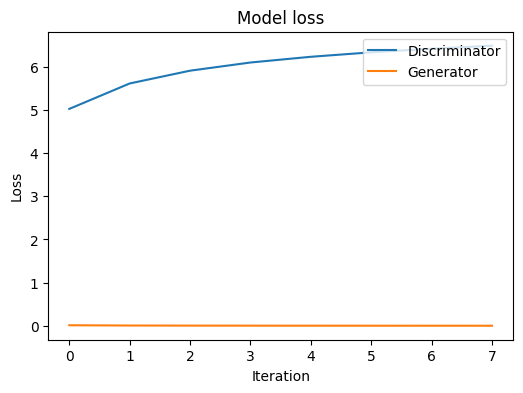

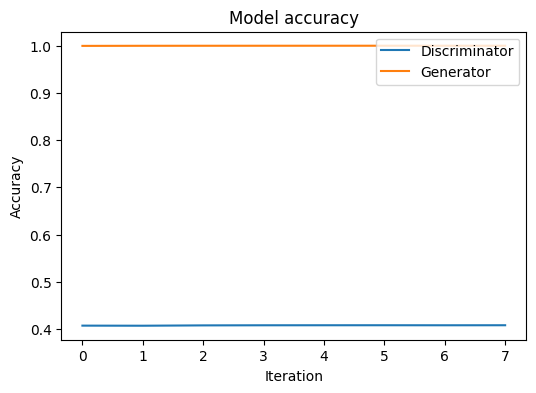

(128, 28, 28)
>3745, D loss-acc [6.489,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3746, D loss-acc [6.490,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3747, D loss-acc [6.490,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3748, D loss-acc [6.490,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3749, D loss-acc [6.490,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3750, D loss-acc [6.490,6.490], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3751, D loss-acc [6.490,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3752, D loss-acc [6.490,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3753, D loss-acc [6.490,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3754, D loss-acc [6.491,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3755, D loss-acc [6.491,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3756, D loss-acc [6.491,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28)
>3757, D loss-acc [6.491,6.491], G/GAN loss-acc [0.002,1.000]
(128, 28, 28

>4212, D loss-acc [6.549,6.550], G/GAN loss-acc [0.001,1.000]
>Saved: model_4212.h5


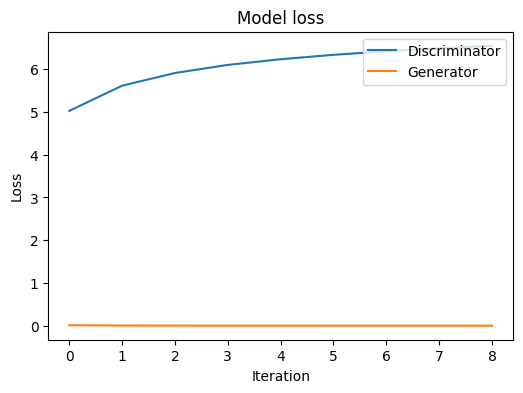

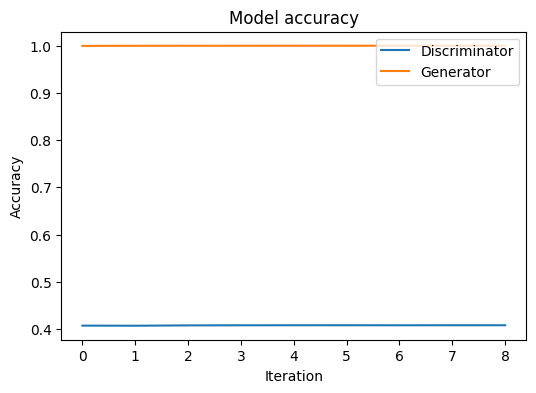

(128, 28, 28)
>4213, D loss-acc [6.549,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4214, D loss-acc [6.550,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4215, D loss-acc [6.550,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4216, D loss-acc [6.550,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4217, D loss-acc [6.550,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4218, D loss-acc [6.550,6.550], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4219, D loss-acc [6.550,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4220, D loss-acc [6.550,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4221, D loss-acc [6.550,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4222, D loss-acc [6.551,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4223, D loss-acc [6.551,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4224, D loss-acc [6.551,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28)
>4225, D loss-acc [6.551,6.551], G/GAN loss-acc [0.001,1.000]
(128, 28, 28

>4680, D loss-acc [6.601,6.601], G/GAN loss-acc [0.001,1.000]
>Saved: model_4680.h5


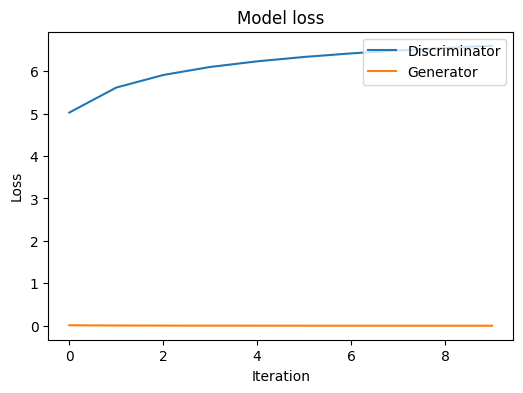

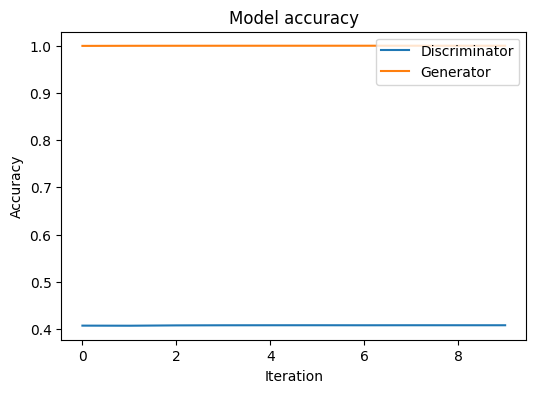

In [90]:
# Train the GAN model
train(generator, discriminator, gan_model, norm_data, latent_dim, n_epochs=10, n_batch=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
(20, 28, 28, 1)


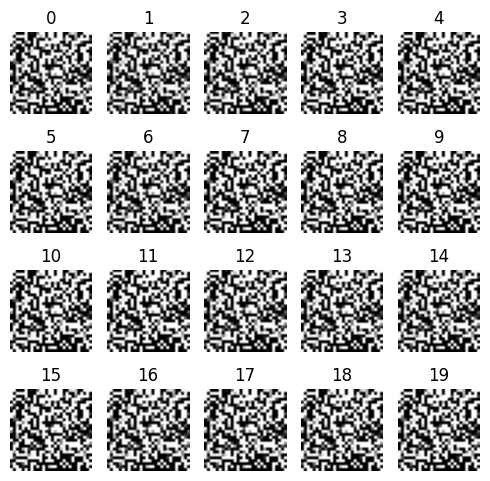

In [91]:
# Try and generate some samples with the GAN
n_examples = 20

latent_points = generate_latent_points(latent_dim, n_examples)
generated_imgs  = generator.predict(latent_points)
print(np.shape(generated_imgs))

generated_imgs = denormalize_data(generated_imgs)
pos = np.arange(n_examples)
visualizeSamples(generated_imgs, pos)


In [92]:
# Build a GAN composed of convolutional layers
def build_generator(latent_dim):
    model = tf.keras.Sequential([


        layers.Dense(7 * 7 * 16, input_dim=latent_dim),
        layers.Reshape((7, 7, 16)),
        layers.Conv2DTranspose(16, (3, 3), activation="tanh", padding="same"),
        layers.UpSampling2D((2, 2)),
        layers.Conv2DTranspose(32, (3, 3), activation="tanh", padding="same"),
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(1, (3, 3), activation="tanh", padding="same")

    ])
    return model

def build_discriminator(input_shape):
    model = keras.Sequential([

        layers.Input(shape=input_shape),
        layers.Flatten(),

        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")

    ])

    opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])\

    return model


In [93]:
latent_dim = 5
input_shape = (28, 28, 1)

print("Input shape for discriminator:", input_shape)

discriminator = build_discriminator(input_shape)

print("DISCRIMINATOR")
discriminator.summary()

generator = build_generator(latent_dim)

print("GENERATOR")
generator.summary()

Input shape for discriminator: (28, 28, 1)
DISCRIMINATOR


c:\Users\Mario\Documents\UNIGE\Unige_code\Master\First\MSC_py_vem\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,460,225 (5.57 MB)

...

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 784)            │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 7, 7, 16)       │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_16 (UpSampling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 14, 14, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,953 (46.69 KB)

 Trainable params: 11,953 (46.69 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
def define_gan(g_model, d_model, latent_dim):
    d_model.trainable = False # This means that when training the generator, the discriminator is not trained

    # Define the input for the GAN (which is the input for the generator)
    gan_input = keras.Input(shape=(latent_dim,))

    # Connect the generator to this input
    generated_image = g_model(gan_input)

    # Connect the discriminator to the generated image
    gan_output = d_model(generated_image)

    # Create the GAN model
    gan_model = keras.Model(gan_input, gan_output)

    opt = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    gan_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return gan_model

# Explicitly build the generator by calling it with a dummy input (for standalone use like summary/prediction)
generator(tf.zeros((1, latent_dim)))
# Explicitly build the discriminator by calling it with a dummy input (for standalone use like summary/prediction)
discriminator(tf.zeros((1, *input_shape)))

gan_model = define_gan(generator, discriminator, latent_dim)
gan_model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_20 (Sequential)      │ (None, 28, 28, 1)      │        11,953 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_19 (Sequential)      │ (None, 1)              │     1,460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,472,178 (5.62 MB)

 Trainable params: 11,953 (46.69 KB)

 Non-trainable params: 1,460,225 (5.57 MB)

(128, 28, 28)
>1, D loss-acc [0.816,0.770], G/GAN loss-acc [0.709,0.414]
(128, 28, 28)
>2, D loss-acc [0.793,0.779], G/GAN loss-acc [0.705,0.434]
(128, 28, 28)
>3, D loss-acc [0.786,0.776], G/GAN loss-acc [0.704,0.435]
(128, 28, 28)
>4, D loss-acc [0.782,0.776], G/GAN loss-acc [0.703,0.447]
(128, 28, 28)
>5, D loss-acc [0.782,0.778], G/GAN loss-acc [0.701,0.469]
(128, 28, 28)
>6, D loss-acc [0.780,0.777], G/GAN loss-acc [0.699,0.474]
(128, 28, 28)
>7, D loss-acc [0.786,0.783], G/GAN loss-acc [0.696,0.484]
(128, 28, 28)
>8, D loss-acc [0.788,0.786], G/GAN loss-acc [0.695,0.494]
(128, 28, 28)
>9, D loss-acc [0.791,0.789], G/GAN loss-acc [0.693,0.503]
(128, 28, 28)
>10, D loss-acc [0.793,0.791], G/GAN loss-acc [0.692,0.516]
(128, 28, 28)
>11, D loss-acc [0.792,0.791], G/GAN loss-acc [0.690,0.534]
(128, 28, 28)
>12, D loss-acc [0.794,0.792], G/GAN loss-acc [0.688,0.547]
(128, 28, 28)
>13, D loss-acc [0.797,0.795], G/GAN loss-acc [0.686,0.565]
(128, 28, 28)
>14, D loss-acc [0.797,0.796], G/

>468, D loss-acc [1.658,1.659], G/GAN loss-acc [0.181,0.977]
>Saved: model_0468.h5


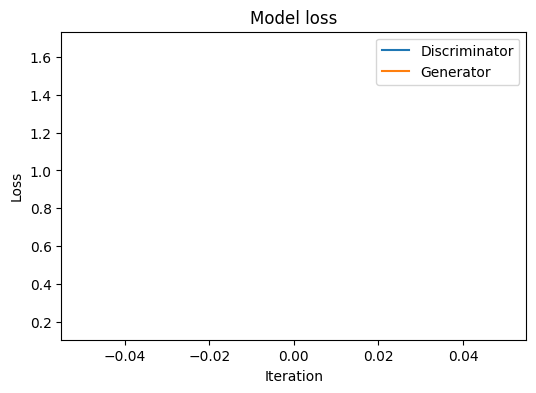

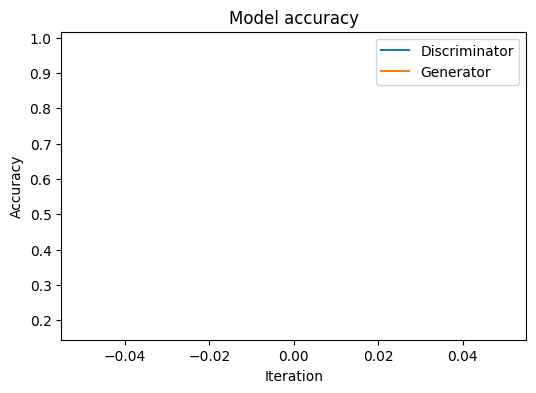

(128, 28, 28)
>469, D loss-acc [1.659,1.660], G/GAN loss-acc [0.180,0.977]
(128, 28, 28)
>470, D loss-acc [1.660,1.661], G/GAN loss-acc [0.180,0.977]
(128, 28, 28)
>471, D loss-acc [1.662,1.663], G/GAN loss-acc [0.180,0.977]
(128, 28, 28)
>472, D loss-acc [1.663,1.664], G/GAN loss-acc [0.180,0.977]
(128, 28, 28)
>473, D loss-acc [1.664,1.665], G/GAN loss-acc [0.179,0.978]
(128, 28, 28)
>474, D loss-acc [1.665,1.666], G/GAN loss-acc [0.179,0.978]
(128, 28, 28)
>475, D loss-acc [1.666,1.667], G/GAN loss-acc [0.179,0.978]
(128, 28, 28)
>476, D loss-acc [1.668,1.669], G/GAN loss-acc [0.178,0.978]
(128, 28, 28)
>477, D loss-acc [1.669,1.670], G/GAN loss-acc [0.178,0.978]
(128, 28, 28)
>478, D loss-acc [1.670,1.671], G/GAN loss-acc [0.178,0.978]
(128, 28, 28)
>479, D loss-acc [1.671,1.672], G/GAN loss-acc [0.178,0.978]
(128, 28, 28)
>480, D loss-acc [1.672,1.673], G/GAN loss-acc [0.177,0.978]
(128, 28, 28)
>481, D loss-acc [1.674,1.675], G/GAN loss-acc [0.177,0.978]
(128, 28, 28)
>482, D los

>936, D loss-acc [2.073,2.074], G/GAN loss-acc [0.104,0.989]
>Saved: model_0936.h5


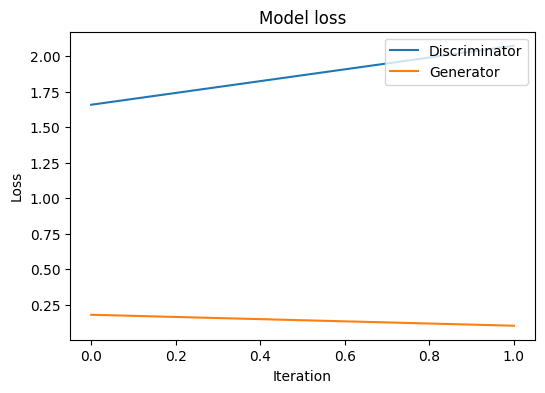

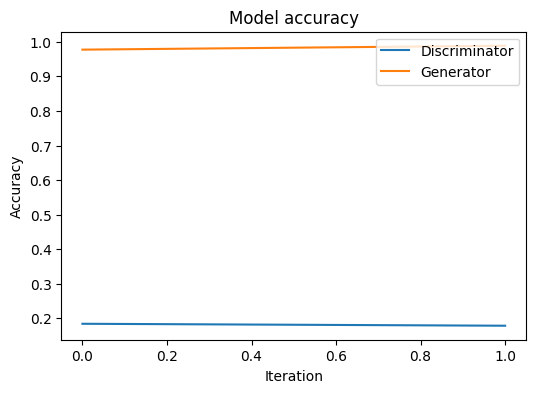

(128, 28, 28)
>937, D loss-acc [2.074,2.074], G/GAN loss-acc [0.104,0.989]
(128, 28, 28)
>938, D loss-acc [2.074,2.075], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>939, D loss-acc [2.075,2.075], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>940, D loss-acc [2.076,2.076], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>941, D loss-acc [2.076,2.077], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>942, D loss-acc [2.077,2.077], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>943, D loss-acc [2.077,2.078], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>944, D loss-acc [2.078,2.079], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>945, D loss-acc [2.079,2.079], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>946, D loss-acc [2.079,2.080], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>947, D loss-acc [2.080,2.081], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>948, D loss-acc [2.081,2.081], G/GAN loss-acc [0.103,0.989]
(128, 28, 28)
>949, D loss-acc [2.081,2.082], G/GAN loss-acc [0.102,0.989]
(128, 28, 28)
>950, D los

>1404, D loss-acc [2.327,2.327], G/GAN loss-acc [0.074,0.992]
>Saved: model_1404.h5


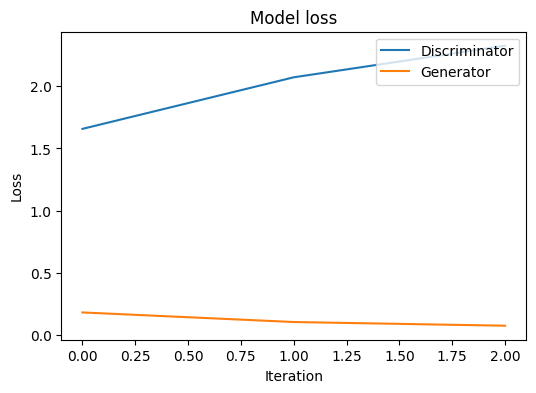

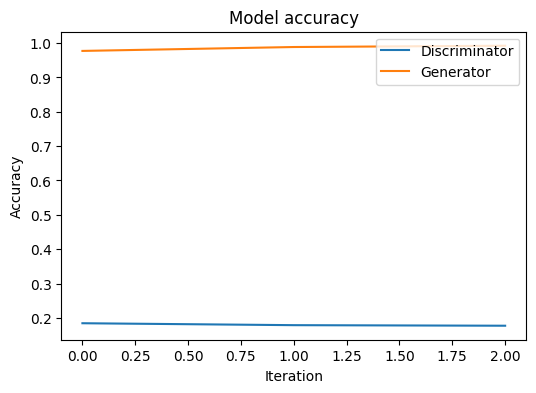

(128, 28, 28)
>1405, D loss-acc [2.327,2.328], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1406, D loss-acc [2.328,2.328], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1407, D loss-acc [2.328,2.329], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1408, D loss-acc [2.329,2.329], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1409, D loss-acc [2.329,2.330], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1410, D loss-acc [2.330,2.330], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1411, D loss-acc [2.330,2.331], G/GAN loss-acc [0.074,0.992]
(128, 28, 28)
>1412, D loss-acc [2.331,2.331], G/GAN loss-acc [0.073,0.992]
(128, 28, 28)
>1413, D loss-acc [2.331,2.331], G/GAN loss-acc [0.073,0.992]
(128, 28, 28)
>1414, D loss-acc [2.331,2.332], G/GAN loss-acc [0.073,0.992]
(128, 28, 28)
>1415, D loss-acc [2.332,2.332], G/GAN loss-acc [0.073,0.992]
(128, 28, 28)
>1416, D loss-acc [2.332,2.333], G/GAN loss-acc [0.073,0.992]
(128, 28, 28)
>1417, D loss-acc [2.333,2.333], G/GAN loss-acc [0.073,0.993]
(128, 28, 28

>1872, D loss-acc [2.517,2.518], G/GAN loss-acc [0.058,0.994]
>Saved: model_1872.h5


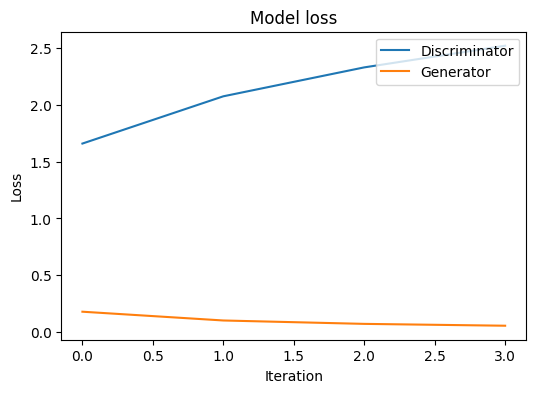

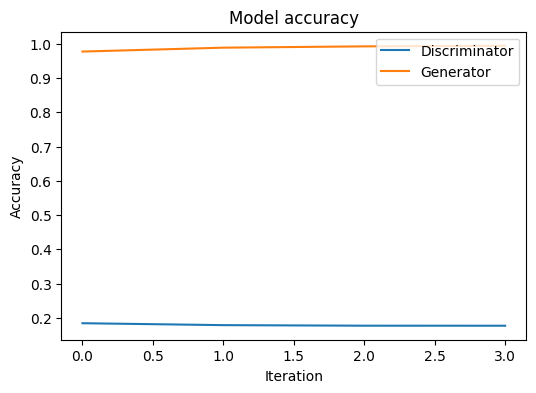

(128, 28, 28)
>1873, D loss-acc [2.518,2.518], G/GAN loss-acc [0.058,0.994]
(128, 28, 28)
>1874, D loss-acc [2.518,2.518], G/GAN loss-acc [0.058,0.994]
(128, 28, 28)
>1875, D loss-acc [2.518,2.519], G/GAN loss-acc [0.058,0.994]
(128, 28, 28)
>1876, D loss-acc [2.519,2.519], G/GAN loss-acc [0.058,0.994]
(128, 28, 28)
>1877, D loss-acc [2.519,2.520], G/GAN loss-acc [0.058,0.994]
(128, 28, 28)
>1878, D loss-acc [2.519,2.520], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1879, D loss-acc [2.520,2.520], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1880, D loss-acc [2.520,2.521], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1881, D loss-acc [2.521,2.521], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1882, D loss-acc [2.521,2.521], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1883, D loss-acc [2.521,2.522], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1884, D loss-acc [2.522,2.522], G/GAN loss-acc [0.057,0.994]
(128, 28, 28)
>1885, D loss-acc [2.522,2.522], G/GAN loss-acc [0.057,0.994]
(128, 28, 28

>2340, D loss-acc [2.669,2.669], G/GAN loss-acc [0.047,0.995]
>Saved: model_2340.h5


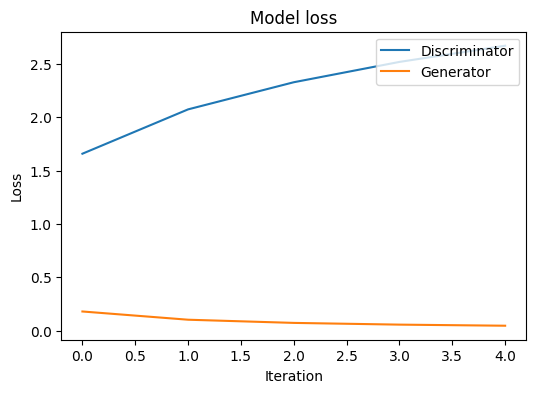

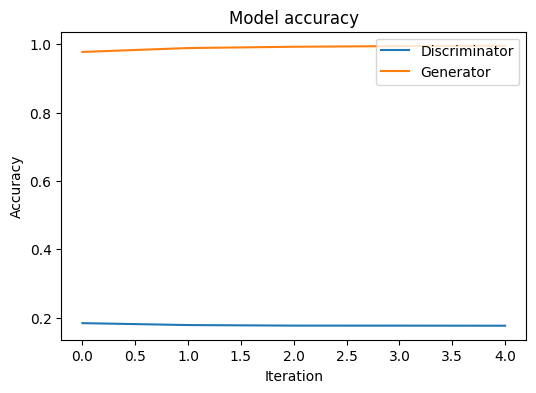

(128, 28, 28)
>2341, D loss-acc [2.669,2.670], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2342, D loss-acc [2.670,2.670], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2343, D loss-acc [2.670,2.670], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2344, D loss-acc [2.670,2.670], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2345, D loss-acc [2.670,2.671], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2346, D loss-acc [2.671,2.671], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2347, D loss-acc [2.671,2.671], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2348, D loss-acc [2.671,2.672], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2349, D loss-acc [2.672,2.672], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2350, D loss-acc [2.672,2.672], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2351, D loss-acc [2.672,2.672], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2352, D loss-acc [2.672,2.673], G/GAN loss-acc [0.047,0.995]
(128, 28, 28)
>2353, D loss-acc [2.673,2.673], G/GAN loss-acc [0.047,0.995]
(128, 28, 28

>2808, D loss-acc [2.796,2.796], G/GAN loss-acc [0.040,0.996]
>Saved: model_2808.h5


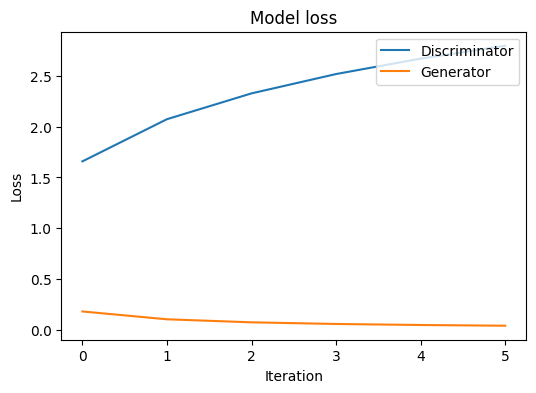

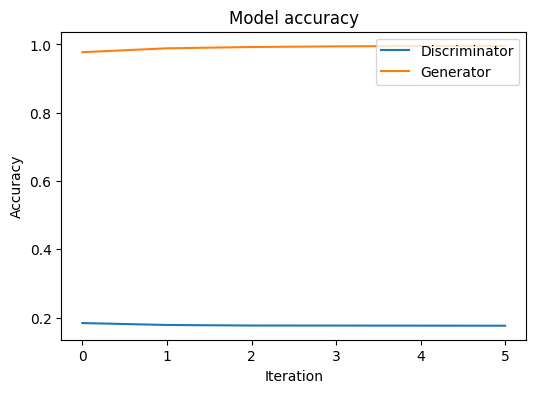

(128, 28, 28)
>2809, D loss-acc [2.796,2.797], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2810, D loss-acc [2.797,2.797], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2811, D loss-acc [2.797,2.797], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2812, D loss-acc [2.797,2.797], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2813, D loss-acc [2.797,2.798], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2814, D loss-acc [2.797,2.798], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2815, D loss-acc [2.798,2.798], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2816, D loss-acc [2.798,2.798], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2817, D loss-acc [2.798,2.798], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2818, D loss-acc [2.798,2.799], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2819, D loss-acc [2.799,2.799], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2820, D loss-acc [2.799,2.799], G/GAN loss-acc [0.040,0.996]
(128, 28, 28)
>2821, D loss-acc [2.799,2.799], G/GAN loss-acc [0.040,0.996]
(128, 28, 28

>3276, D loss-acc [2.906,2.906], G/GAN loss-acc [0.035,0.997]
>Saved: model_3276.h5


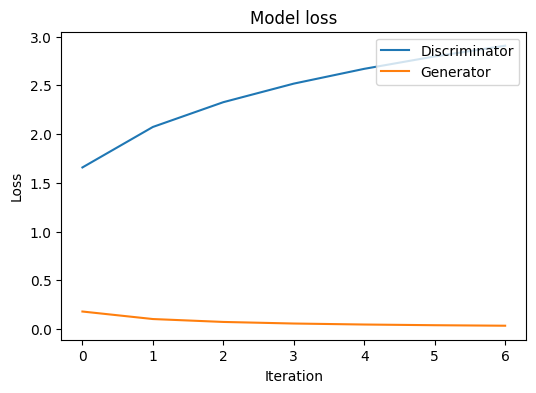

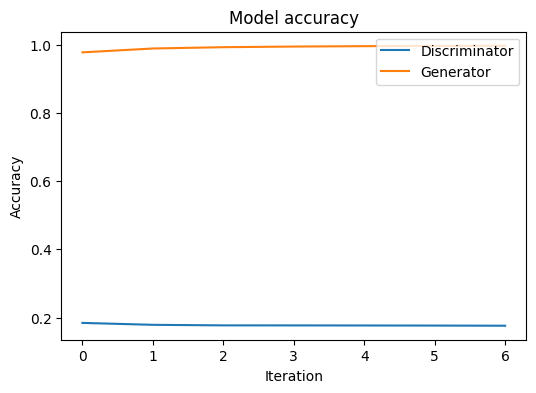

(128, 28, 28)
>3277, D loss-acc [2.906,2.906], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3278, D loss-acc [2.906,2.907], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3279, D loss-acc [2.907,2.907], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3280, D loss-acc [2.907,2.907], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3281, D loss-acc [2.907,2.907], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3282, D loss-acc [2.907,2.907], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3283, D loss-acc [2.907,2.908], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3284, D loss-acc [2.908,2.908], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3285, D loss-acc [2.908,2.908], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3286, D loss-acc [2.908,2.908], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3287, D loss-acc [2.908,2.909], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3288, D loss-acc [2.908,2.909], G/GAN loss-acc [0.035,0.997]
(128, 28, 28)
>3289, D loss-acc [2.909,2.909], G/GAN loss-acc [0.035,0.997]
(128, 28, 28

>3744, D loss-acc [3.001,3.001], G/GAN loss-acc [0.031,0.997]
>Saved: model_3744.h5


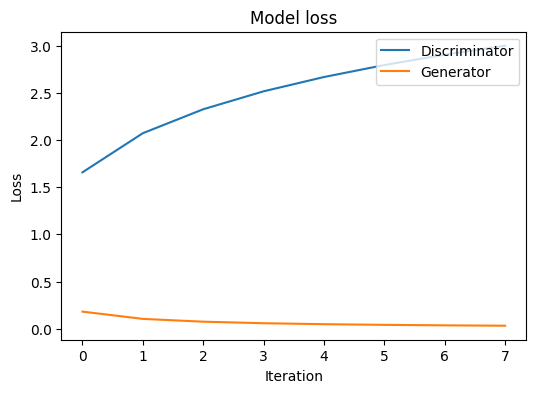

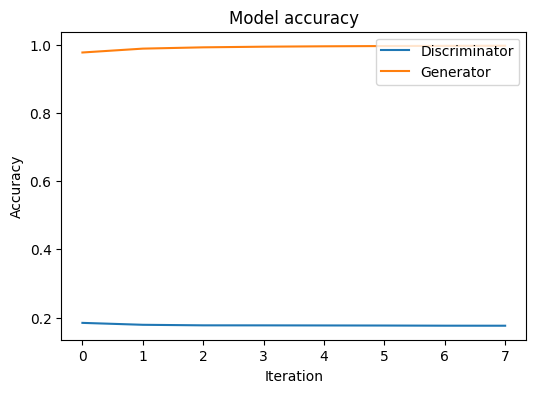

(128, 28, 28)
>3745, D loss-acc [3.001,3.001], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3746, D loss-acc [3.001,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3747, D loss-acc [3.001,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3748, D loss-acc [3.002,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3749, D loss-acc [3.002,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3750, D loss-acc [3.002,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3751, D loss-acc [3.002,3.002], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3752, D loss-acc [3.002,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3753, D loss-acc [3.003,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3754, D loss-acc [3.003,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3755, D loss-acc [3.003,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3756, D loss-acc [3.003,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28)
>3757, D loss-acc [3.003,3.003], G/GAN loss-acc [0.031,0.997]
(128, 28, 28

>4212, D loss-acc [3.084,3.084], G/GAN loss-acc [0.028,0.997]
>Saved: model_4212.h5


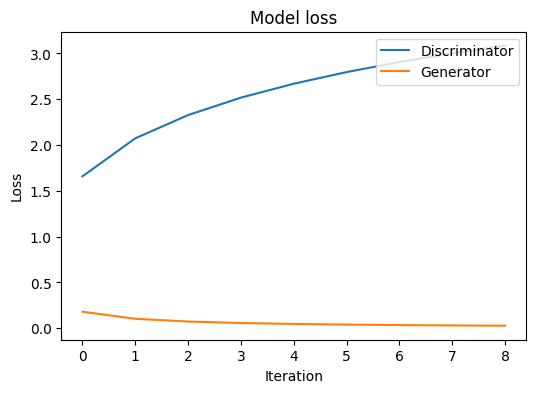

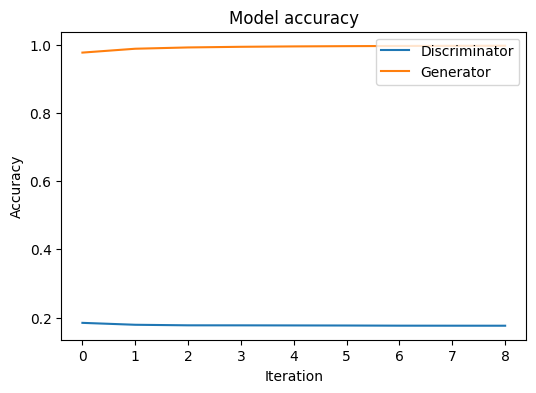

(128, 28, 28)
>4213, D loss-acc [3.084,3.084], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4214, D loss-acc [3.084,3.084], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4215, D loss-acc [3.084,3.084], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4216, D loss-acc [3.084,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4217, D loss-acc [3.085,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4218, D loss-acc [3.085,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4219, D loss-acc [3.085,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4220, D loss-acc [3.085,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4221, D loss-acc [3.085,3.085], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4222, D loss-acc [3.085,3.086], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4223, D loss-acc [3.086,3.086], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4224, D loss-acc [3.086,3.086], G/GAN loss-acc [0.028,0.997]
(128, 28, 28)
>4225, D loss-acc [3.086,3.086], G/GAN loss-acc [0.028,0.997]
(128, 28, 28

>4680, D loss-acc [3.158,3.158], G/GAN loss-acc [0.025,0.998]
>Saved: model_4680.h5


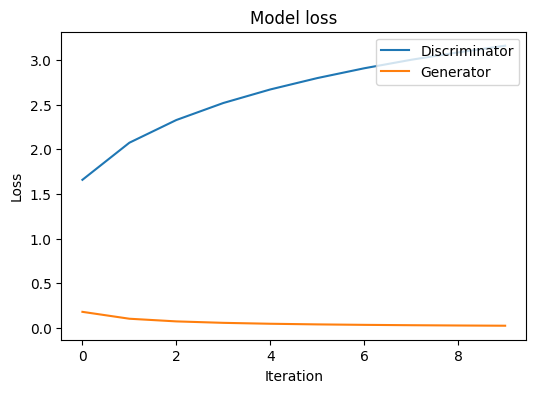

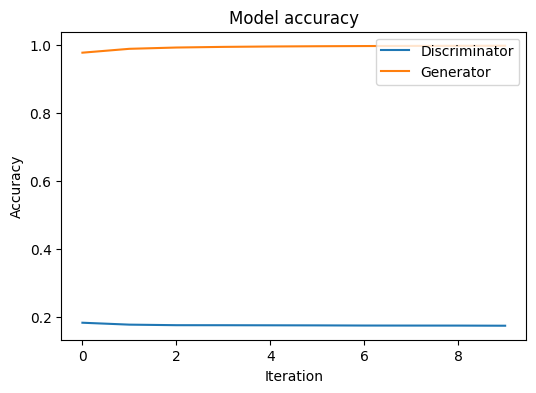

In [95]:
# Train the GAN model
train(generator, discriminator, gan_model, norm_data, latent_dim, n_epochs=10, n_batch=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
(20, 28, 28, 1)


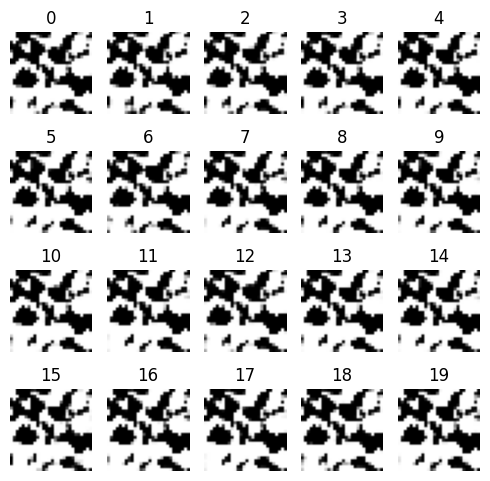

In [96]:
# Try and generate some samples with the GAN
n_examples = 20

latent_points = generate_latent_points(latent_dim, n_examples)
generated_imgs  = generator.predict(latent_points)
print(np.shape(generated_imgs))

generated_imgs = denormalize_data(generated_imgs)
pos = np.arange(n_examples)
visualizeSamples(generated_imgs, pos)